                                               Relatório número 1
                                                    Grupo 3

**Discentes** :

Charanga, Luís

Djata, Amissane

Macicame, Brénden


# Aplicação Estatística a problemas reais da Biologia

Nesta aula vamos analisar o crescimento de **6 microrganismos** em cultura pura, extrair parâmetros biológicos das curvas de crescimento, e aplicar testes estatísticos para comparar os organismos entre si.

**Organismos em estudo:**

| Organismo | Tipo | Patogenicidade | Ambiente natural |
|---|---|---|---|
| *E. coli* K12 | Bactéria Gram− | Comensal | Intestino humano |
| *Salmonella enterica* | Bactéria Gram− | Patogénico | Intestino, alimentos |
| *L. acidophilus* | Bactéria Gram+ | Comensal/probiótico | Intestino, vagina |
| *C. difficile* | Bactéria Gram+ | Patogénico | Intestino (oportunista) |
| *S. cerevisiae* | Levedura | Comensal/probiótico | Intestino humano, alimentos, solo |
| *C. albicans* | Levedura | Patogénico (oportunista) | Intestino, vagina |

## Curvas de Crescimento

O crescimento microbiano segue um padrão **sigmoidal** bem caracterizado, com fases distintas: **lag**, **exponencial**, **estacionária** e **declínio**. A análise quantitativa destas curvas permite extrair parâmetros biológicos que descrevem o comportamento de cada cultura.

---

### Parâmetros-chave

| Parâmetro | Símbolo | Significado biológico | Unidade |
|---|---|---|---|
| Plateau | **A** | Densidade ótica máxima atingida (capacidade de carga) | OD600 |
| Taxa de crescimento máxima | **μ_max** | Inclinação máxima da curva — quão rápido as células se dividem | OD/h |
| Fase lag | **λ** | Tempo que a cultura demora a iniciar o crescimento exponencial | horas |

---

### Porquê estes parâmetros?

Estes três parâmetros permitem responder a questões práticas importantes, como:
- **Segurança alimentar:** Quanto tempo demora um patogénico a começar a multiplicar-se num alimento? (λ)
- **Produção industrial:** Qual o organismo que atinge maior biomassa? (A)
- **Competição entre espécies:** Quem cresce mais rápido e pode dominar uma co-cultura? (μ_max)


In [16]:
# Importar Pacotes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# FASE 1 — Carregar e visualizar os dados

Antes de qualquer cálculo, é fundamental **olhar para os dados**. Vamos carregar o ficheiro CSV com as leituras de OD600 ao longo do tempo para as 6 estirpes (3 réplicas cada).

### 1.1 Abrir as medições de crescimento microbiano

O ficheiro `crescimento_microbiano.csv` contém leituras de **densidade ótica a 600 nm (OD600)** ao longo de 24 horas para as 6 estirpes, com 3 réplicas biológicas cada.

A OD600 é uma medida indireta da **concentração de células** em suspensão — quanto mais células, mais luz é dispersa e maior o valor de OD.

**Estrutura dos dados:**
- Cada **linha** = uma réplica de uma estirpe
- Cada **coluna** numérica = um ponto temporal (em horas)
- Colunas `Strain` e `Replicate` = identificação da amostra


In [17]:
# Carregar o CSV numa dataframe pandas
df=pd.read_csv("crescimento_microbiano.csv")

In [18]:
print("Boas práticas: ")
print("Verifica as primeiras linhas do DataFrame:")
display(df.head)

Boas práticas: 
Verifica as primeiras linhas do DataFrame:


<bound method NDFrame.head of                  Strain Replicate      0    0.5      1    1.5      2    2.5  \
0            E_coli_K12        R1  0.142  0.110  0.150  0.196  0.290  1.106   
1            E_coli_K12        R2  0.002  0.017  0.000  0.000  0.204  0.956   
2            E_coli_K12        R3  0.000  0.000  0.000  0.000  0.073  0.964   
3   Salmonella_enterica        R1  0.000  0.000  0.026  0.000  0.014  0.148   
4   Salmonella_enterica        R2  0.000  0.000  0.033  0.004  0.000  0.184   
5   Salmonella_enterica        R3  0.195  0.270  0.184  0.188  0.176  0.251   
6         L_acidophilus        R1  0.000  0.000  0.000  0.000  0.000  0.000   
7         L_acidophilus        R2  0.086  0.178  0.167  0.164  0.169  0.118   
8         L_acidophilus        R3  0.000  0.000  0.000  0.000  0.000  0.000   
9           C_difficile        R1  0.232  0.286  0.351  0.319  0.246  0.317   
10          C_difficile        R2  0.000  0.000  0.000  0.000  0.000  0.000   
11          C_difficil

#### **Questão**

- Quantas medições temos no total? (linhas × colunas de tempo)
- Os valores de OD no tempo 0 são todos iguais? O que poderia explicar pequenas diferenças?

## Respostas

### 1. Quantas medições temos no total?

Temos:

* **18 linhas** = 6 estirpes × 3 réplicas
* **20 colunas de tempo** = 0 até 24 h


Total de medições OD600: 360
### 2. Os valores de OD no tempo 0 são todos iguais? O que pode explicar pequenas diferenças no tempo 0?
Não.
As diferenças no OD600 inicial podem ser explicadas por:
Diferenças no inóculo inicial, erro de pipetagem, mistura incompleta da suspensão celular, ruído do equipamento, Diferenças biológicas entre réplicas

In [19]:
print("Verificar quais as condições a analisar")
print("Estirpe:")
print(df["Strain"].unique())

print("Réplicas por estirpe:")
print(df["Replicate"].unique())
print(df["Strain"].value_counts())

Verificar quais as condições a analisar
Estirpe:
['E_coli_K12' 'Salmonella_enterica' 'L_acidophilus' 'C_difficile'
 'S_cerevisiae' 'C_albicans']
Réplicas por estirpe:
['R1' 'R2' 'R3']
Strain
E_coli_K12             3
Salmonella_enterica    3
L_acidophilus          3
C_difficile            3
S_cerevisiae           3
C_albicans             3
Name: count, dtype: int64


In [5]:
df.head()

,Strain,Replicate,0,0.5,1,1.5,2,2.5,3,3.5,...,5,6,7,8,9,10,12,16,20,24
0,E_coli_K12,R1,0.142,0.110,0.150,0.196,0.290,1.106,2.092,2.571,...,2.872,2.891,2.929,2.822,2.831,2.889,2.867,2.933,2.872,2.847
1,E_coli_K12,R2,0.002,0.017,0.000,0.000,0.204,0.956,1.928,2.399,...,2.884,2.810,2.760,2.855,2.753,2.824,2.716,2.747,2.824,2.851
2,E_coli_K12,R3,0.000,0.000,0.000,0.000,0.073,0.964,1.824,2.239,...,2.655,2.739,2.763,2.758,2.670,2.696,2.728,2.760,2.688,2.702
3,Salmonella_enterica,R1,0.000,0.000,0.026,0.000,0.014,0.148,0.727,1.537,...,2.531,2.407,2.596,2.562,2.543,2.563,2.459,2.548,2.576,2.632
4,Salmonella_enterica,R2,0.000,0.000,0.033,0.004,0.000,0.184,0.793,1.596,...,2.462,2.494,2.598,2.599,2.587,2.575,2.516,2.566,2.570,2.547


#### **Questão**
- No total quantas estirpes vamos analisar?
- E quantas réplicas temos por análise?

### **Respostas**
-Temos no total 6 estirpes. 


-Temos 3 réplicas por analisar

In [20]:
print("\nEstatísticas descritivas:")
print(df.describe())


Estatísticas descritivas:
               0        0.5          1        1.5          2        2.5  \
count  18.000000  18.000000  18.000000  18.000000  18.000000  18.000000   
mean    0.062778   0.068000   0.068222   0.075778   0.094833   0.240500   
std     0.082119   0.093634   0.096481   0.096642   0.095648   0.366672   
min     0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
25%     0.000000   0.000000   0.000000   0.000000   0.000000   0.002250   
50%     0.001000   0.020500   0.022500   0.022500   0.082000   0.094500   
75%     0.113000   0.101500   0.134500   0.153000   0.165750   0.234250   
max     0.232000   0.286000   0.351000   0.319000   0.290000   1.106000   

               3        3.5          4        4.5          5          6  \
count  18.000000  18.000000  18.000000  18.000000  18.000000  18.000000   
mean    0.511278   0.715778   0.858000   0.919222   0.951389   1.096889   
std     0.727000   0.976802   1.147606   1.211050   1.265501   1.176608 

#### **Questão**
- Como varia o desvio padrão com o tempo?

Resposta


O desvio-padrão apresentou valores baixos nos momentos iniciais do ensaio, indicando reduzida variabilidade no crescimento logístico entre as seis estirpes avaliadas, incluindo bactérias e leveduras. A partir de 2,5 h, verificou-se um aumento progressivo da dispersão, sugerindo diferenças mais acentuadas nas taxas de crescimento entre as 3 réplicas durante a fase de maior atividade metabólica. Essa variabilidade atingiu o valor máximo no tempo de 5 h (SD = 1,266), evidenciando o ponto de maior heterogeneidade no comportamento de crescimento. Após esse período, observou-se uma diminuição gradual do desvio-padrão até 24 h, indicando uma tendência à estabilização do crescimento logístico e maior homogeneidade entre as 3 réplicas ao longo do tempo.

### Atribuição de estirpes por grupo

Cada grupo altera a variável `estirpe` na célula seguinte para o seu organismo:

| Grupo | Organismo | Tipo |
|---|---|---|
| 1 | `E_coli_K12` | Bactéria comensal |
| 2 | `Salmonella_enterica` | Bactéria patogénica |
| 3 | `L_acidophilus` | Bactéria probiótica |
| 4 | `C_difficile` | Bactéria patogénica |
| 5 | `S_cerevisiae` | Levedura comensal |
| 6 | `C_albicans` | Levedura patogénica |




#### **Questão**
Antes de correr o código, o que esperam? 
- Um patogénico cresce mais rápido que um comensal?
- Uma levedura cresce mais devagar que uma bactéria?

Resposta

O fato de um microrganismo ser patogénico ou comensal não determina necessariamente a sua velocidade de crescimento, pois isso depende da espécie(factores bióticos) e das condições ambientais. Contudo, geralmente, os patogénicos crescem lentamente, enquanto os comensais multiplicam-se rapidamente. 

Em geral, as bactérias crescem mais rápido que as leveduras, porque possuem estrutura celular mais simples e metabolismo mais acelerado. Por outro lado, as leveduras, por serem estrutural e funcionalmente complexas (organismos eucariotas), normalmente apresentam crescimento mais lento.


Isto é, alguns patogénicos crescem lentamente, enquanto certos comensais podem multiplicar-se rapidamente, e as bactérias crescem mais rápido que as leveduras.

### 1.2 Filtrar os dados da vossa estirpe

Filtramos a dataframe de maneira a selecionar apenas as linhas correspondentes à estirpe escolhida, e removemos as colunas não numéricas (Strain, Replicate).

In [21]:
estirpe = "L_acidophilus" # defina a estirpe a analisar

df_estirpe = df[df["Strain"] == estirpe] # filtrar o dataframe para a estirpe escolhida
print(df_estirpe)

# ----Filtrar a dataframe para as colunas com dados apenas
#print('Colunas de tempo')

columns = df.columns.to_list() 
print(columns) # LISTA o nome das colunas do dataframe
time_cols =columns[2:]  # mantém apenas as colunas de tempo (assumindo que as 2 primeiras são 'Strain' e 'Replicate')
print(time_cols)
                  
#print(f"DataFrame filtrado para a estirpe {estirpe}:\n{df_estirpe_time.head(5)}")

          Strain Replicate      0    0.5      1    1.5      2    2.5      3  \
6  L_acidophilus        R1  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
7  L_acidophilus        R2  0.086  0.178  0.167  0.164  0.169  0.118  0.163   
8  L_acidophilus        R3  0.000  0.000  0.000  0.000  0.000  0.000  0.000   

     3.5  ...      5      6      7      8      9     10     12     16     20  \
6  0.000  ...  0.000  0.486  1.116  1.420  1.715  1.876  1.803  1.910  1.914   
7  0.167  ...  0.307  0.693  1.359  1.684  1.993  2.120  2.093  2.199  2.172   
8  0.000  ...  0.051  0.669  1.138  1.470  1.681  1.866  1.903  1.967  1.956   

      24  
6  1.940  
7  2.193  
8  1.929  

[3 rows x 22 columns]
['Strain', 'Replicate', '0', '0.5', '1', '1.5', '2', '2.5', '3', '3.5', '4', '4.5', '5', '6', '7', '8', '9', '10', '12', '16', '20', '24']
['0', '0.5', '1', '1.5', '2', '2.5', '3', '3.5', '4', '4.5', '5', '6', '7', '8', '9', '10', '12', '16', '20', '24']


### 1.3 Calcular média e desvio-padrão de todos os tempos

Para cada ponto temporal, calculamos a **média** e o **desvio-padrão** das 3 réplicas.

- A **média** dá-nos o valor central da medição
- O **desvio-padrão** indica a variabilidade entre réplicas — se é pequeno, as réplicas são consistentes


In [22]:
# --- Usa a dataframe 'df_estirpe' para calcular os valores da média

print(df_estirpe)
od_mean = df_estirpe[time_cols].mean().values # selecionar valores e calcular média para cada tempo
print(f"Médias calculadas por cada periodo de tempo analisado:\n{od_mean}")

od_std  = df_estirpe[time_cols].std().values # calcular desvio-padrão para cada tempo
print(f"Desvios-padrão:\n{od_std}")

time_array = np.array(time_cols, dtype=float) # criar array de tempos a das colunas de tempo array-list of values
print(f"Array de tempos (horas): {time_array}")

          Strain Replicate      0    0.5      1    1.5      2    2.5      3  \
6  L_acidophilus        R1  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
7  L_acidophilus        R2  0.086  0.178  0.167  0.164  0.169  0.118  0.163   
8  L_acidophilus        R3  0.000  0.000  0.000  0.000  0.000  0.000  0.000   

     3.5  ...      5      6      7      8      9     10     12     16     20  \
6  0.000  ...  0.000  0.486  1.116  1.420  1.715  1.876  1.803  1.910  1.914   
7  0.167  ...  0.307  0.693  1.359  1.684  1.993  2.120  2.093  2.199  2.172   
8  0.000  ...  0.051  0.669  1.138  1.470  1.681  1.866  1.903  1.967  1.956   

      24  
6  1.940  
7  2.193  
8  1.929  

[3 rows x 22 columns]
Médias calculadas por cada periodo de tempo analisado:
[0.02866667 0.05933333 0.05566667 0.05466667 0.05633333 0.03933333
 0.05433333 0.05566667 0.04       0.11       0.11933333 0.616
 1.20433333 1.52466667 1.79633333 1.954      1.933      2.02533333
 2.014      2.02066667]
Desvios-padrão:
[0.0

#### **Questão:**

Olhando para a média dos valores, consegues antever:
- quando acaba a fase de adaptação do crescimento (lag)?
- quando começa  afase de crescimento exponencial?
- quando se inicia a fase estacinária?

Respostas 

A fase de adaptação (lag) estendeu-se aproximadamente até às 5 h, período em que as médias apresentaram variações reduzidas, refletindo a adaptação inicial das culturas. A partir desse ponto, entre 5 e 10 h, observou-se o início da fase de crescimento exponencial, caracterizada por um aumento acentuado das médias e, simultaneamente, por maior dispersão entre as réplicas, indicando diferenças nas taxas de crescimento. A fase estacionária iniciou-se por volta das 10–12 h, quando as médias tenderam à estabilização e a variabilidade diminuiu, evidenciando maior homogeneidade entre as réplicas 

### 1.4 Representação gráfica

Vamos representar a curva de crescimento com a média ± desvio-padrão (barras de erro), mas também todas as réplicas individualmente.


          Strain Replicate      0    0.5      1    1.5      2    2.5      3  \
6  L_acidophilus        R1  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
7  L_acidophilus        R2  0.086  0.178  0.167  0.164  0.169  0.118  0.163   
8  L_acidophilus        R3  0.000  0.000  0.000  0.000  0.000  0.000  0.000   

     3.5  ...      5      6      7      8      9     10     12     16     20  \
6  0.000  ...  0.000  0.486  1.116  1.420  1.715  1.876  1.803  1.910  1.914   
7  0.167  ...  0.307  0.693  1.359  1.684  1.993  2.120  2.093  2.199  2.172   
8  0.000  ...  0.051  0.669  1.138  1.470  1.681  1.866  1.903  1.967  1.956   

      24  
6  1.940  
7  2.193  
8  1.929  

[3 rows x 22 columns]
Strain       L_acidophilus
Replicate               R1
0                      0.0
0.5                    0.0
1                      0.0
1.5                    0.0
2                      0.0
2.5                    0.0
3                      0.0
3.5                    0.0
4                      0.

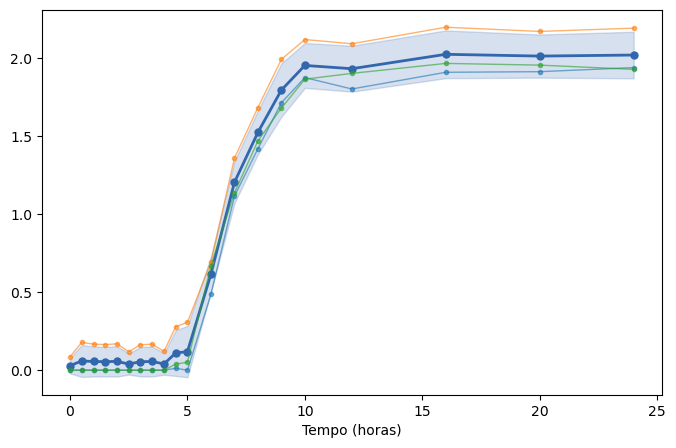

In [23]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'

fig, ax = plt.subplots(figsize=(8, 5))

# ────── Curva dos valores médios de crescimento
ax.plot(time_array, od_mean, #X = time, Y= média de OD em cada tempo
        "o-", color="#3266ad", linewidth=2, markersize=5, label='Média, n=3')

# ────── Curva dos valores de cada réplicas individual
print(df_estirpe)
for i, row in df_estirpe.iterrows():
    print(row)
    ax.plot(time_array, row[time_cols], #X = time, Y= valores de OD em CADA TEMPO
    "o-", linewidth=1, markersize=3, alpha=0.6, label=row["Replicate"]) # label usando o nome da réplica


# ────── Banda de desvio padrão
ax.fill_between(time_array, od_mean-od_std,  od_mean+od_std,  # X = time, Y_baixo = valor mais baixo (média - std), Y_alto = valor mais alto (média + std)
   color="#3266ad", alpha=0.2, label="± SD")

ax.set_xlabel("Tempo (horas)")
#ax.set_ylabel("OD600")
#ax.set_title("Estimativa gráfica dos parâmetros")
#ax.legend()

#mostra a imagem e fecha, permitindo a continua alteração da imagem
display(fig)
plt.close()

### **Questão**
- Conseguem identificar as fases lag, exponencial e estacionária?
- Como se comparam as diferentes réplicas individualmente com a média e desvio padrão?


**Respostas**

As três réplicas mostram o mesmo padrão geral: fase lag até cerca de 5 h, crescimento exponencial entre 5–10 h e fase estacionária a partir de 10–12 h. R2 cresce mais cedo e apresenta valores mais altos, enquanto R1 e R3 mostram crescimento mais tardio. O desvio-padrão é maior quando há diferenças entre as réplicas, especialmente porque R2 começa a crescer antes das outras.

# FASE 2 — Calcular os parâmetros de crescimento

Agora vamos passar da observação ao cálculo. Para cada estirpe, vamos estimar os 3 parâmetros de crescimento a partir dos dados:

| Passo | O que vamos fazer | Parâmetro | 
|-------|-------------------|-----------|
| 2.1 | Estimar o plateau (média dos últimos pontos) | **A** |
| 2.2 | Calcular a taxa máxima de crescimento (ΔOD/Δt) | **μ_max** |
| 2.3 | Estimar a fase lag a partir do ponto de inflexão | **λ** |

Cada grupo vai analisar **um microrganismo** e no final juntamos os resultados de todos.

### 2.1 Crescimento máximo — Plateau ou Fase Estacionária (A)

O plateau (A) representa a **densidade ótica máxima** que a cultura atinge — o ponto em que o crescimento estabiliza porque os nutrientes se esgotam ou os produtos tóxicos se acumulam.

Estimamos A como a **média dos últimos pontos temporais**, onde a curva já estabilizou.

**O que determina o valor de A?**
- **Capacidade de carga do meio:** quantidade de nutrientes disponíveis
- **Tolerância a produtos metabólicos:** ácidos, etanol, toxinas que se acumulam
- **Tamanho celular:** a mesma OD600 pode corresponder a números diferentes de células conforme o organismo (bactérias são mais pequenas que leveduras)

**Questão:** 
- Se duas estirpes crescem no mesmo meio, mas uma atinge um plateau mais alto, o que pode explicar a diferença?

**Resposta**

Um plateau mais alto pode ser explicado por maior capacidade de utilização dos nutrientes, melhor tolerância aos produtos metabólicos acumulados ou diferenças no tamanho/morfologia celular, resultando em maior densidade ótica final.

Valores selecionados: [1.954      1.933      2.02533333 2.014      2.02066667]

Estimativas gráficas para L_acidophilus:
  Plateau (A) média ≈ 1.9893999999999998
  R1: Plateau ≈ 1.889
  R2: Plateau ≈ 2.155
  R3: Plateau ≈ 1.924


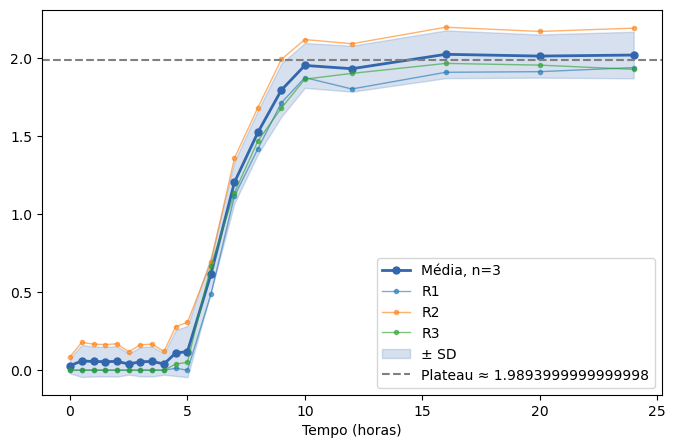

In [24]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'


# ─────────────── Plateau (A) ─────────────────────────────────────────
# ────── Calcular o plateu médio
valor_incial_A =15 # em que valor a reta entra em A?
valores_A = od_mean[valor_incial_A:] # selecionar os valores a partir do tempo onde a curva parece estabilizar (usar o array de médias)
print(f"Valores selecionados: {valores_A}")

A_estimado =valores_A.mean() # calcular a média dos valores para obter a estimativa do plateau
print(f"\nEstimativas gráficas para {estirpe}:")
print(f"  Plateau (A) média ≈ {A_estimado}")

#visualiza o valor médio do plateau no gráfico
ax.axhline(A_estimado, color="gray", linestyle="--", label=f"Plateau ≈ {A_estimado}") 
ax.legend()

# ────── Calcular o plateau para cada réplica individualmente
for i, row in df_estirpe.iterrows():      # loop por cada réplica usando df_estirpe
    od_rep = row[time_cols].values
    # seleciona as colunas de valores → guarda os values de OD
    d_A_rep =od_rep[valor_incial_A:]                     # valores de A
    A_rep =d_A_rep.mean()                          # média → estimativa do plateau
    print(f"  {row['Replicate']}: Plateau ≈ {A_rep:.3f}")


display(fig)
plt.close()

### 2.2 Taxa de crescimento máxima (μ_max)

A taxa de crescimento máxima corresponde à **inclinação máxima** da curva — o momento em que as células se estão a dividir mais rapidamente (fase exponencial).

Calculamos μ_max como a derivada numérica da curva:

$$\mu_{max} = \max\left(\frac{\Delta OD}{\Delta t}\right)$$

Ou seja, para cada par de pontos consecutivos calculamos a variação de OD por hora (ΔOD/Δt) e ficamos com o **valor máximo**.

**O que influencia μ_max?**
- **Tipo de divisão celular:** bactérias (fissão binária, ~20 min) vs leveduras (gemulação, ~90 min)
- **Meio de cultura:** disponibilidade de nutrientes, temperatura, pH
- **Metabolismo:** aeróbio vs anaeróbio, fermentativo vs respiratório


Taxa de crescimento (ΔOD): [ 0.03066667 -0.00366667 -0.001       0.00166667 -0.017       0.015
  0.00133333 -0.01566667  0.07        0.00933333  0.49666667  0.58833333
  0.32033333  0.27166667  0.15766667 -0.021       0.09233333 -0.01133333
  0.00666667]
Intervalos de tempo (Δt): [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 1.  1.  1.  1.  1.  2.  4.  4.
 4. ]
Taxa de crescimento por hora (ΔOD/Δt): [ 0.06133333 -0.00733333 -0.002       0.00333333 -0.034       0.03
  0.00266667 -0.03133333  0.14        0.01866667  0.49666667  0.58833333
  0.32033333  0.27166667  0.15766667 -0.0105      0.02308333 -0.00283333
  0.00166667]
 Valor máximo de μ_max no ARRAY de valores é: 0.5883333333333333
O crescimento máximo de 0.5883333333333333 OD/h ocorre no tempo de 6.0 horas
  R1: μ_max ≈ 0.6300000000000001 OD/h
  R2: μ_max ≈ 0.666 OD/h
  R3: μ_max ≈ 0.618 OD/h
Estimativas gráficas para L_acidophilus:
  Plateau (A)  ≈ 1.989
  μ_max        ≈ 0.588 OD/h


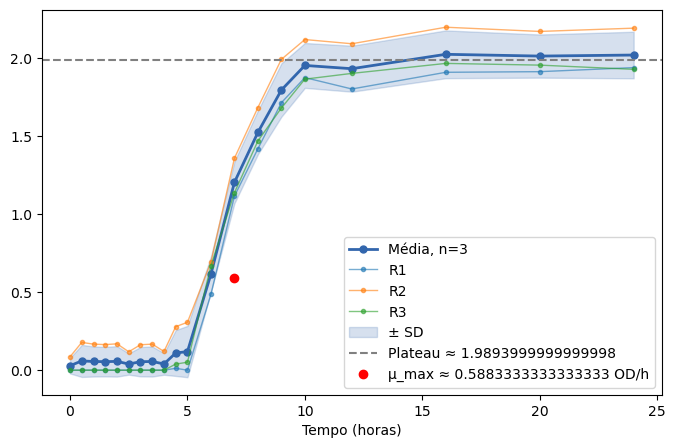

In [25]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'


# ─────────────── Taxa máxima (mu) ────────────────────────────────────

# ────── Calcular o mu médio
# -- np (numpy é usado para trabalhar com arrays e fazer operações amtemáticas)
dod = np.diff(od_mean) # calcular a diferença entre os valores de OD para obter a taxa de crescimento
print(f"Taxa de crescimento (ΔOD): {dod}")

dt = np.diff(time_array) # calcular intervalo de tempo
print(f"Intervalos de tempo (Δt): {dt}")

dod_dt = dod/dt # aplicar a fórmula da taxa de crescimento (ΔOD/Δt)
print(f"Taxa de crescimento por hora (ΔOD/Δt): {dod_dt}")

mu_estimado  =max(dod_dt)  # encontrar o valor máximo de μ_max no ARRAY de valores

print(f" Valor máximo de μ_max no ARRAY de valores é: {mu_estimado}")
idx_max = np.argmax(dod_dt) # encontrar o índice no array no valor máximo
time_mu_max  = time_array[idx_max] # para identificar o tempo correspondente
print(f"O crescimento máximo de {mu_estimado} OD/h ocorre no tempo de {time_mu_max} horas")

# ────── Calcular mu para cada réplica individualmente
for i, row in df_estirpe.iterrows():
    od_rep      = row[time_cols].values # extrair os valores de OD da réplica
    dod_dt_rep  = np.diff(od_rep)/dt # calcular a taxa de crescimento da réplica
    mu_rep      = dod_dt_rep.max()        # estimar μ_max da réplica
    
    print(f"  {df_estirpe.loc[i, 'Replicate']}: μ_max ≈ {mu_rep} OD/h")

# --- plot no gráfico
ax.plot(time_array[idx_max] +1, dod_dt[idx_max], "o", color="red", 
        label=f"μ_max ≈ {mu_estimado} OD/h")
ax.legend()

print(f"Estimativas gráficas para {estirpe}:")
print(f"  Plateau (A)  ≈ {A_estimado:.3f}")
print(f"  μ_max        ≈ {mu_estimado:.3f} OD/h")

display(fig)
plt.close()

### 2.3 Estimativa da Fase Lag (λ)

A fase lag é calculada a partir do ponto de inflexão da curva:

$$\lambda = t_{inf} - \frac{OD_{inf} - OD_0}{\mu_{max}}$$

Onde:
- **lambda** — tempo da fase lag (se λ = 2 horas, significa que a cultura ficou cerca de 2 horas em adaptação antes de crescer rapidamente)
- **t_inf** — tempo no ponto de inflexão (onde o crescimento é mais rápido)
- **OD_inf** — valor de OD nesse ponto
- **OD_0** — valor de OD no tempo zero
- **μ_max** — taxa de crescimento máxima (calculada no passo anterior)

Ouuuu....

Podemos estimar quando a OD ultrapassa o valor de inicial.

#### **Questão:** 
- Um organismo com uma fase lag longa é vantajoso ou desvantajoso? Depende do contexto?


**Resposta**

Depende de contexto, pode ser vanatajoso ou desvantajoso


Desvantajoso quando o objetivo é crescer rapidamente, porque uma fase lag longa atrasa o aumento da população.
Vantajoso quando o organismo precisa de tempo para se adaptar a um novo ambiente, ativar genes de stress ou resistir a condições desfavoráveis.
Isto é,
Uma fase lag longa pode ser desvantajosa por atrasar o crescimento, mas pode ser vantajosa quando permite melhor adaptação ao ambiente antes da divisão celular

Limite de crescimento em fase Lag: 0.12866666666666668
Valores acima do threshold: [False False False False False False False False False False False  True
  True  True  True  True  True  True  True  True]
Tempos acima do crescimento lag: [ 6.  7.  8.  9. 10. 12. 16. 20. 24.]
Tempo que o crescimento sai de fase lag: 6.0
R1: Lag ≈ 6.0 h
R2: Lag ≈ 0.5 h
R3: Lag ≈ 6.0 h
Estimativas gráficas para L_acidophilus:
  Plateau (A)  ≈ 1.9893999999999998
  μ_max        ≈ 0.5883333333333333 OD/h
  Fase lag     ≈ 6.0 h


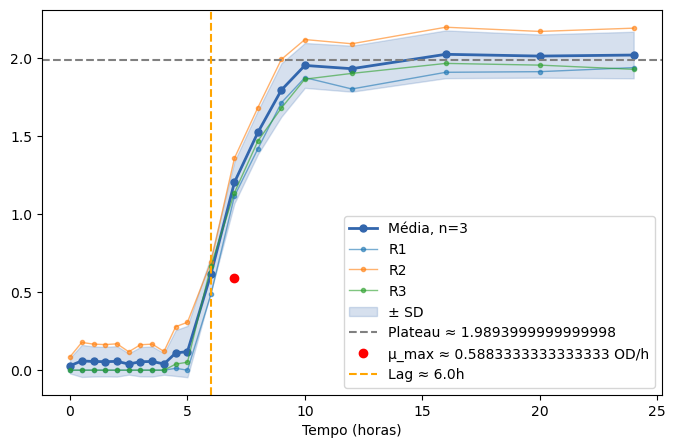

In [12]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'
# ────── Calcular lambda da média
threshold = od_mean[0] + 0.1 # OD inicial + margem para ignorar ruído
print(f"Limite de crescimento em fase Lag: {threshold}")
array_valores_acima_threshold = od_mean > threshold # cria um array booleano (True/False) dos valores de od_mean acima do threshold defnido
print(f"Valores acima do threshold: {array_valores_acima_threshold}")

valores_tempo_acima_threshold = time_array[array_valores_acima_threshold] # Retira os valores de tempo onde True
print(f"Tempos acima do crescimento lag: {valores_tempo_acima_threshold}")

lam_estimado =valores_tempo_acima_threshold[0] # primeiro tempo onde OD ultrapassa o threshold
print(f"Tempo que o crescimento sai de fase lag: {lam_estimado}")

# ────── Calcular lambada para cada réplica individualmente
for i, row in df_estirpe.iterrows():
    od_rep = row[time_cols].values
    threshold = od_mean[0] + 0.1
    above = od_rep > threshold
    t_above = time_array[above]
    if len(t_above) > 0:
        lam_rep = t_above[0]
    else:
        lam_rep = None
    print(f"{row['Replicate']}: Lag ≈ {lam_rep} h")

ax.axvline(lam_estimado, color="orange", linestyle="--", label=f"Lag ≈ {lam_estimado}h") # representar graficamente
ax.legend()

print(f"Estimativas gráficas para {estirpe}:")
print(f"  Plateau (A)  ≈ {A_estimado}")
print(f"  μ_max        ≈ {mu_estimado} OD/h")
print(f"  Fase lag     ≈ {lam_estimado} h")

display(fig)
plt.close()

# FASE 3 — Comparar o crescimento das diferentes estirpes

### 3.1 Tabela resumo dos parâmetros de crescimento

Depois de estimados os parâmetros para todas as estirpes, compilamos os resultados numa tabela com a **média ± desvio-padrão** (3 réplicas) de cada parâmetro:

| Parâmetro | O que representa | Como foi estimado |
|---|---|---|
| **A** (mean ± sd) | Plateau — densidade máxima atingida | Média dos últimos 5 pontos temporais |
| **μ_max** (mean ± sd) | Taxa de crescimento máxima | Máximo de ΔOD/Δt na fase exponencial |
| **λ** (mean ± sd) | Fase lag — tempo até iniciar crescimento | Fórmula: λ = t_inf − (OD_inf − OD₀) / μ_max |

A tabela resultante terá este formato — **uma linha por estirpe, com média e desvio-padrão de cada parâmetro**:

| Strain | Replicate | A_mean | A_sd | mu_mean | mu_sd | lam_mean | lam_sd |
|---|---|---|---|---|---|---|---|
| C_albicans | ... | ... | ... | ... | ... | ... | ... |
| C_difficile | ... | ... | ... | ... | ... | ... | ... |
| E_coli_K12 | ... | ... | ... | ... | ... | ... | ... |
| L_acidophilus | ... | ... | ... | ... | ... | ... | ... |
| S_cerevisiae | ... | ... | ... | ... | ... | ... | ... |
| Salmonella_enterica | ... | ... | ... | ... | ... | ... | ... |



In [14]:
# --- Para o cálculo de todos os dados usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'
#print(df)
#────── Criar dataframe vazia para guardar os resultados
df_resultados = pd.DataFrame(columns = ["Strain", "Replicate", "A", "mu", "lam"])

#────── Criar função para calcular os diferentes parâmetros de crescimento
def calcular_parametros(t, od): # cria função para calcular os parÂmetros de crescimento
    
    # Plateau — média dos últimos 20% dos pontos
    n_plateau = int(0.2 * len(od))
    A = od[-n_plateau:].mean()
    # mu máximo
    dod_dt = np.diff(od)/np.diff(t)
    idx_max = np.argmax(dod_dt)
    mu =dod_dt[idx_max]
    
    # Fase lag — threshold
    threshold=od[0]+0.1
    lam=t[od > threshold][0]
    
    return A, mu, lam

#────── Calcular e armazenar os parâmetros de crescimento para todas as estirpes
for estirpe in df["Strain"].unique():# iterar por estirpe
    print(estirpe)
    df_estirpe = df[df["Strain"]==estirpe] # filtrar por estirpe
    print(df_estirpe)
    df_estirpe_time =df_estirpe[time_cols]    # manter apenas colunas com valores de crescimento-times_cols
    print( df_estirpe_time)

    for i, row in df_estirpe_time.iterrows(): # iterar por réplica

        od_rep =row.values # valores de OD da linha 
        print(od_rep)
        A, mu, lam = calcular_parametros(time_array, od_rep)

        #guardar resultados
        df_resultados.loc[i, "Strain"]    = estirpe
        df_resultados.loc[i, "Replicate"] = df_estirpe.loc[i, "Replicate"]
        df_resultados.loc[i, "A"] = A
        df_resultados.loc[i, "mu"] = mu
        df_resultados.loc[i, "lam"] = lam


print("Parâmetros por réplica:")
print(df_resultados)

#────── Colapsar em valores médios, calculando o desvio padrão
df_resumo = df_resultados.groupby("Strain").agg(  #agrupar as diferentes linhas pela coluna strain, agregando...
    A_mean=("A", "mean"), A_sd=("A", "std"), # coluna A_mean em que agregamos os valores de A pela média e coluna A_std em que agregamos os valores de A pelo desvio padrão
    mu_mean=("mu", "mean"), mu_sd=("mu", "std"),
    lam_mean=("lam", "mean"), lam_sd=("lam", "std"),
).round(3)
print("\nResumo (média ± SD por estirpe):")
print(df_resumo)

E_coli_K12
       Strain Replicate      0    0.5     1    1.5      2    2.5      3  \
0  E_coli_K12        R1  0.142  0.110  0.15  0.196  0.290  1.106  2.092   
1  E_coli_K12        R2  0.002  0.017  0.00  0.000  0.204  0.956  1.928   
2  E_coli_K12        R3  0.000  0.000  0.00  0.000  0.073  0.964  1.824   

     3.5  ...      5      6      7      8      9     10     12     16     20  \
0  2.571  ...  2.872  2.891  2.929  2.822  2.831  2.889  2.867  2.933  2.872   
1  2.399  ...  2.884  2.810  2.760  2.855  2.753  2.824  2.716  2.747  2.824   
2  2.239  ...  2.655  2.739  2.763  2.758  2.670  2.696  2.728  2.760  2.688   

      24  
0  2.847  
1  2.851  
2  2.702  

[3 rows x 22 columns]
       0    0.5     1    1.5      2    2.5      3    3.5      4    4.5      5  \
0  0.142  0.110  0.15  0.196  0.290  1.106  2.092  2.571  2.741  2.886  2.872   
1  0.002  0.017  0.00  0.000  0.204  0.956  1.928  2.399  2.647  2.725  2.884   
2  0.000  0.000  0.00  0.000  0.073  0.964  1.824  2.239 

#### **Questão:** 
- Qual a estirpe com maior variabilidade (SD alto) em cada parâmetro? O que pode explicar isso?

A estirpe com maior variabilidade em cada parâmetro foi a C_difficile, com os seguintes SD:

A → C_difficile com SD = 0.196

μ  → Saccharomyces cerevisiae e C_difficile com SD = 0.057

λ  → C_difficile com SD = 2.646

Isso sugere que C_difficile apresentou o comportamento mais inconsistente entre as réplicas experimentais. Essa alta variabilidade pode ser explicada por sensibilidade às condições de cultura, adaptação desigual ao meio, diferenças fisiológicas entre células ou maior dificuldade de crescimento em ambiente experimental, enquanto que valores baixos de SD indicam crescimento mais estável e reprodutível.


### 3.1 Simulação das curvas de crescimento — Modelo de Gompertz

Tendo os 3 parâmetros estimados (A, μ_max, λ) para cada estirpe, podemos reconstruir a curva de crescimento completa usando o **modelo de Gompertz modificado**:

$$OD(t) = A \cdot \exp\left(-\exp\left(\frac{\mu_{max} \cdot e}{A} \cdot (\lambda - t) + 1\right)\right)$$

Isto permite-nos **sobrepor todas as estirpes no mesmo gráfico** e comparar visualmente.

| Parâmetro | Símbolo | Unidade | Significado biológico |
|---|---|---|---|
| Medida de Crescimento | OD(t) | h | OD da população de microrganismos no tempo \(t\)|
| Tempo | t | h | Variável independente — o tempo decorrido desde o início do ensaio. |
| Número de Euler | e | — | Constante matemática (≈ 2,718).|

Fórmula:
- A estrutura é uma **exponencial dupla** (exp dentro de exp), o que gera a forma sigmoide assimétrica característica.
- O termo **e** na fórmula é o número de Euler (≈ 2,718), e aparece como fator de escala que garante que μ_max corresponda exatamente à taxa máxima de crescimento — é uma consequência da derivação matemática do modelo, não um parâmetro ajustável.
- O argumento interno, **(μ_max · e / A) · (λ − t) + 1**, controla a transição entre as fases.
- Quando **t ≪ λ**, (λ − t) é grande e positivo, a exponencial interna é muito grande, e a exponencial externa tende a zero — a população ainda não cresceu.
- Quando **t ≫ λ**, (λ − t) torna-se muito negativo, a exponencial interna tende a zero, e OD(t) tende a A — a população atingiu o máximo.
- A transição entre estes extremos dá-nos a **fase exponencial**.

                       A_mean   A_sd   mu_mean  mu_sd  lam_mean  lam_sd
Strain                                                                 
C_albicans           1.535417  0.039  0.257333  0.032       8.0   0.000
C_difficile           2.18425  0.196      0.52  0.057       4.0   2.646
E_coli_K12           2.794583  0.081  1.899333  0.103  2.166667   0.289
L_acidophilus         1.99825  0.146     0.638  0.025       5.5   0.866
S_cerevisiae          2.21275  0.046     0.421  0.057  6.666667   0.577
Salmonella_enterica  2.624917  0.127  1.584667  0.050  2.666667   0.289
Linha temporal criada: [ 0.          0.12060302  0.24120603  0.36180905  0.48241206  0.60301508
  0.72361809  0.84422111  0.96482412  1.08542714  1.20603015  1.32663317
  1.44723618  1.5678392   1.68844221  1.80904523  1.92964824  2.05025126
  2.17085427  2.29145729  2.4120603   2.53266332  2.65326633  2.77386935
  2.89447236  3.01507538  3.13567839  3.25628141  3.37688442  3.49748744
  3.61809045  3.73869347  3.85929648

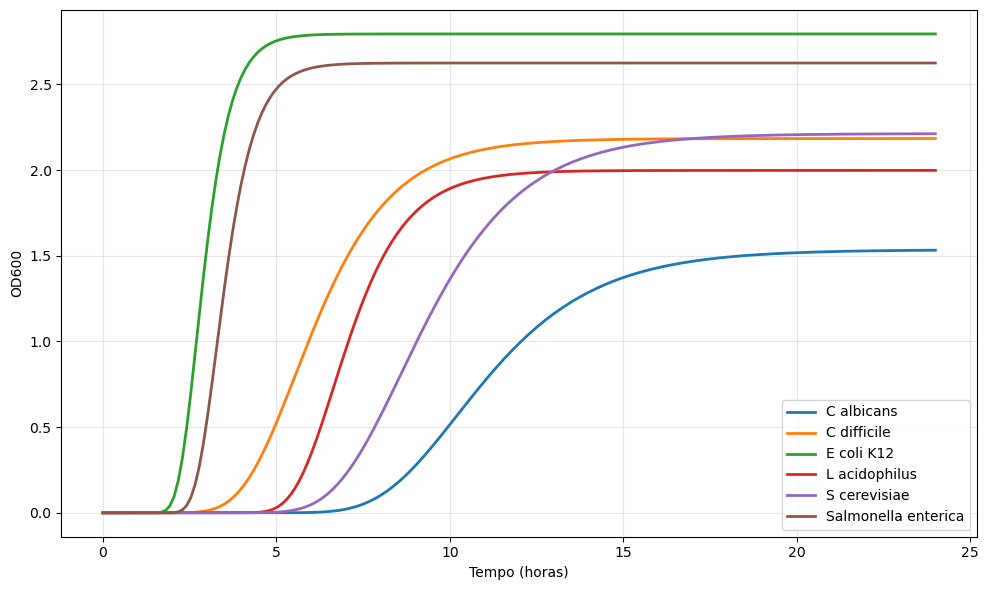

In [26]:
# Para a simulação usa a dataframe df_resumo
print(df_resumo)

# ────── Cria o gráfico
fig_all, ax_all = plt.subplots(figsize=(10, 6))

# ────── Função que faz a simulação da curva por estirpe
def gompertz(t, A, mu, lam):
    return A* np.exp(-np.exp((mu*np.e / A)*(lam-t)+1))  #Tenta completar a fórmula. Lembra-te que o np permite operações matemáticas (np.exp, np.e)
    
# ---np.linspace(start, stop, num) — cria um array de num valores igualmente espaçados entre start e stop.
t_curva = np.linspace(0, time_array[-1], 200)
print(f"Linha temporal criada: {t_curva}")

# ──────simula a curva por cada estirpe
for estirpe in df_resumo.index.unique():       #onde estão as estirpes detalhadas?
    params   = df_resumo.loc[estirpe]        #retira os valores da estirpe da df_resumo
    print(params)                                      #retira os valores da estirpe da df_resumo
    od_curva = gompertz(t_curva, params ["A_mean"], params ["mu_mean"], params ["lam_mean"]) #insere os valores necessários para a função
    ax_all.plot(t_curva,od_curva, linewidth=2, label=estirpe.replace("_", " "))    #plota a linha no gráfico - X = tempo, Y = ods calculados por gompertz

ax_all.set_xlabel("Tempo (horas)")
ax_all.set_ylabel("OD600")
ax_all.legend()
ax_all.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Questão:** 

- Quem arranca primeiro? (λ mais curto = curva desloca-se para a esquerda)
- Quem cresce mais rápido? (μ_max maior = curva mais íngreme)
- Quem atinge maior densidade? (A maior = plateau mais alto)

- Olhando para o gráfico, consigam identificar os dois grandes grupos (bactérias vs leveduras). O que os distingue?

**Respostas**

Quem arranca primeiro?

E_coli_K12, porque tem o menor λ


Quem cresce mais rápido?

E_coli_K12, porque tem o maior μ_max 


Quem atinge maior densidade?

E_coli_K12, porque tem o maior A


Quais são os dois grandes grupos?

Bactérias e leveduras.


O que distingue os grupos?


As bactérias arrancam mais cedo, crescem mais rápido e têm maior μ_max.
As leveduras têm fase lag mais longa e crescimento mais lento.

### 3.2 Visualização comparativa de parâmetros de crescimento

Para facilitar a comparação dos parâmetros de crescimento, é possivel criar visualização de gráfico de barras de todas as estirpes.

                       A_mean   A_sd   mu_mean  mu_sd  lam_mean  lam_sd
Strain                                                                 
C_albicans           1.535417  0.039  0.257333  0.032       8.0   0.000
C_difficile           2.18425  0.196      0.52  0.057       4.0   2.646
E_coli_K12           2.794583  0.081  1.899333  0.103  2.166667   0.289
L_acidophilus         1.99825  0.146     0.638  0.025       5.5   0.866
S_cerevisiae          2.21275  0.046     0.421  0.057  6.666667   0.577
Salmonella_enterica  2.624917  0.127  1.584667  0.050  2.666667   0.289
lista de estirpes: ['C_albicans', 'C_difficile', 'E_coli_K12', 'L_acidophilus', 'S_cerevisiae', 'Salmonella_enterica']


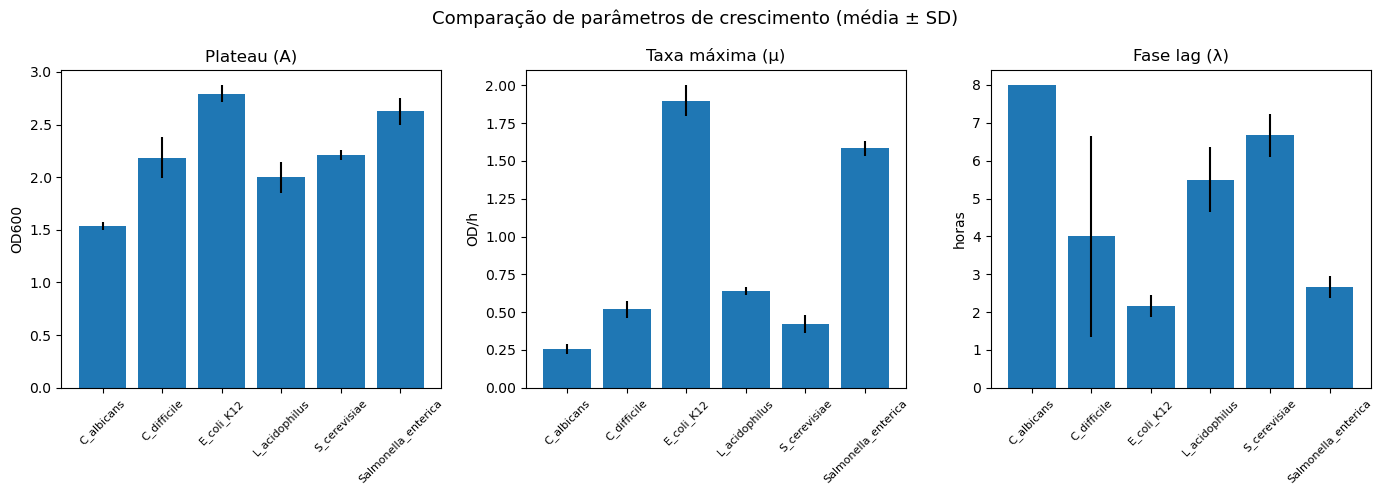

In [27]:
#  Para a visualização usa a dataframe 'df_resumo'

print(df_resumo)

# ──────Cria figura com espaço para 3 gráficos
fig_bar, ax_bar = plt.subplots(1, 3, figsize=(14, 5))

# --- No params_plot definimos que o que queremos ver em cada gráfico
# --- mean_col, sd_col, titulo, unidade 
params_plot = [
    ("A_mean",   "A_sd",   "Plateau (A)",    "OD600"),
    ("mu_mean",  "mu_sd",  "Taxa máxima (µ)", "OD/h"),
    ("lam_mean", "lam_sd", "Fase lag (λ)",    "horas"),
]

#estirpes = df_resumo.keys() # retira as estirpes da df_resumo - index
#estirpes = df_resumo["Strain"].values
#estirpes = df_resumo.index.values
estirpes = df_resumo.index.to_list()
print(f"lista de estirpes: {estirpes}")

# ────── Criar um gráfico de barras para cada parâmetro e cada estirpe
# --- O zip vai retirar os todos os valores em ax_bar e params_plot
for ax, (mean_col, sd_col, titulo, unidade) in zip(ax_bar, params_plot):
    valores =df_resumo[mean_col].values #Retira da df_resumo os values da média - media_col
    erros   =df_resumo[sd_col].values #Retira da df_resumo os values da média - sd_co
    bars = ax.bar(estirpes, valores, yerr=erros) # X = estirpes, Y = valores de média, yerr = valores para as barras de erro
    ax.set_xticks(range(len(estirpes)))
    ax.set_xticklabels(estirpes, fontsize=8, rotation=45)
    ax.set_title(titulo)
    ax.set_ylabel(unidade)
plt.suptitle("Comparação de parâmetros de crescimento (média ± SD)", fontsize=13)
plt.tight_layout()
plt.show()

#### **Questão:** 
- Comparem A com μ_max: os organismos que crescem mais rápido são os que atingem maior densidade?

**Resposta**

Os organismos que crescem mais rápido tendem a atingir maior densidade final, como E_coli_K12 e Salmonella_enterica.
No entanto, isso não é uma regra absoluta, pois S_cerevisiae cresce mais lentamente, mas atinge um plateau relativamente alto.

Com isto, podemos concluir: maior μ_max geralmente acompanha maior A, mas o plateau também depende do metabolismo e da adaptação da estirpe.

In [ ]:
print(df_resumo.columns)
print(df_resumo.head())

In [ ]:
print(type(estirpes))
print(type(valores))
print(type(erros))

print(valores)
print(erros)

### 3.3 Os parâmetros de crescimento são estatisticamente diferentes entre estirpes?

Visualmente, as curvas e gráficos de barras parecem diferentes — mas será que essas diferenças são **estatisticamente significativas** ou podem ser apenas variabilidade experimental?

Para responder, vamos aplicar:

1. **ANOVA One-way** — testa se existe pelo menos uma estirpe diferente das outras (para cada parâmetro)
2. **Tukey HSD (Honestly Significant Difference)** (post-hoc) — se a ANOVA for significativa, identifica **quais pares** de estirpes são diferentes

Relembrando:
- **p < 0.05** → diferença significativa (rejeitamos H₀)
- **p ≥ 0.05** → sem evidência de diferença (não rejeitamos H₀)


In [28]:
# Valores a usar estão na dataframe 'df_resultados' e a lista de estirpes na variável 'estirpe'

print(df_resultados)
print(estirpe)

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:
    # ── Preparar Valores ────────────────────
    # criar um dicionário com os valores do parâmetro por estirpe
    grupos = {}

    for e in estirpes:
        df_estirpe_params = df_resultados[df_resultados["Strain"] == e]  # filtrar para a estirpe
        grupos[e] = df_estirpe_params[param].values.astype(float) # array para o parÂmetro (já tens a variável no primeiro for loop, com os 3 values das réplicas e converte em float (.astype)
    #print(f"Grupos: {grupos}")

    # ── ANOVA entre todas as estirpes ────────────────────
    f_stat, p_anova = stats.f_oneway(*grupos.values()) # * grupos = a stats.f_oneway(grupos["E_coli_K12"], grupos["Salmonella_enterica"], grupos["L_acidophilus"], ...)
     #--- *grupos.values(): [1.5065  1.51975 1.58   ] [2.39325 2.00575 2.15375] [2.87975 2.7845  2.7195 ] [1.89175 2.16425 1.93875] [2.21225 2.167   2.259  ] [2.55375 2.54975 2.77125]
    print(f"\nANOVA (todas as estirpes): F={f_stat}, p={p_anova}")

    # ── Tukey HSD post-hoc ───────────────────────────────
    valores = np.concatenate(list(grupos.values()))
    #  --- np.concatenate(list(grupos.values())) - [1.5065  1.51975 1.58    2.39325 2.00575 2.15375 2.87975 2.7845  ....
    labels = np.repeat(list(grupos.keys()), 3) # diz que cada 3 valores são a réplica de uma espécie
    tukey   = pairwise_tukeyhsd(valores, labels, alpha=0.05)
    print("\nTukey HSD:")
    print(tukey.summary())

                 Strain Replicate        A     mu  lam
0            E_coli_K12        R1  2.87975  1.972  2.0
1            E_coli_K12        R2   2.7845  1.944  2.0
2            E_coli_K12        R3   2.7195  1.782  2.5
3   Salmonella_enterica        R1  2.55375   1.62  2.5
4   Salmonella_enterica        R2  2.54975  1.606  2.5
5   Salmonella_enterica        R3  2.77125  1.528  3.0
6         L_acidophilus        R1  1.89175   0.63  6.0
7         L_acidophilus        R2  2.16425  0.666  4.5
8         L_acidophilus        R3  1.93875  0.618  6.0
9           C_difficile        R1  2.39325  0.501  1.0
10          C_difficile        R2  2.00575  0.584  5.0
11          C_difficile        R3  2.15375  0.475  6.0
12         S_cerevisiae        R1  2.21225  0.486  7.0
13         S_cerevisiae        R2    2.167  0.378  6.0
14         S_cerevisiae        R3    2.259  0.399  7.0
15           C_albicans        R1   1.5065  0.221  8.0
16           C_albicans        R2  1.51975  0.281  8.0
17        

#### **Questões**

- Para qual dos 3 parâmetros (A, μ, λ) existem mais diferenças significativas entre estirpes?
- Há estirpes que não são significativamente diferentes entre si? Quais? Faz sentido biologicamente?
- *E. coli* e *Salmonella* (ambas Enterobacteriaceae) têm parâmetros semelhantes? E *S. cerevisiae* e *C. albicans* (ambas leveduras)?


**Respostas**

-O parâmetro com mais diferenças significativas é μ_max.

-Sim, há estirpes sem diferenças significativas entre si.


Para A:
E_coli_K12 e Salmonella_enterica não diferem significativamente.


Para μ_max:
C_difficile e L_acidophilus não diferem significativamente;
C_difficile e S_cerevisiae também não diferem significativamente.
Para λ:
há várias estirpes sem diferenças significativas, indicando tempos de arranque semelhantes.

Sim, faz sentido biologicamente, porque estirpes próximas ou com metabolismo semelhante podem apresentar crescimento parecido.


-E_coli_K12 e Salmonella_enterica são parcialmente semelhantes:
têm A e λ semelhantes, mas diferem em μ_max.
S_cerevisiae e C_albicans são parcialmente semelhantes:
têm λ semelhante, mas diferem em A e μ_max



### 3.4 Os parâmetros de crescimento são estatisticamente diferentes entre Bactérias e Leveduras

Agora agrupamos os organismos por **tipo** (bactérias vs leveduras) e testamos se há diferenças entre os dois grupos.

**Teste t de Student** — compara as médias de **dois grupos** para determinar se a diferença entre eles é estatisticamente significativa (p < 0,05).


In [29]:
# ══════════════════════════════════════════════════════════
# ANÁLISE POR GRUPO — bactérias vs leveduras
# ══════════════════════════════════════════════════════════
bacterias = ["E_coli_K12", "Salmonella_enterica", "L_acidophilus", "C_difficile"]
leveduras = ["S_cerevisiae", "C_albicans"]

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:

    # criar um dicionário com os valores do parâmetro por estirpe
    grupos = {}
    for e in estirpes:
        df_estirpe_params = df_resultados[df_resultados["Strain"] == e]  # filtrar para a estirpe
        grupos[e] = df_estirpe_params[param].values.astype(float)  # array com os 3 valores das réplicas

    #DIFERENÇA
    # juntar todos os valores de bactérias num único array
    vals_bact = np.concatenate([grupos[e] for e in bacterias])
    print('ex: vals_bact variável: {vals_bact}')
    # juntar todos os valores de leveduras num único array
    vals_lev  = np.concatenate([grupos[e] for e in leveduras])

    # ── t-test bactérias vs leveduras ────────────────────
    # -- ttest_ind(valores de crescimento das bacterias, valores de crescimento das leveduras)
    t_stat, p_ttest = stats.ttest_ind(vals_bact, vals_lev)
    print(f"\nt-test bactérias vs leveduras para {titulo}: t={t_stat:.3f}, p={p_ttest:.4f}")
    print(f"  bactérias: média={vals_bact.mean():.3f} ± {vals_bact.std():.3f}")
    print(f"  leveduras: média={vals_lev.mean():.3f} ± {vals_lev.std():.3f}")

ex: vals_bact variável: {vals_bact}

t-test bactérias vs leveduras para Plateau (A): t=2.905, p=0.0103
  bactérias: média=2.400 ± 0.342
  leveduras: média=1.874 ± 0.340
ex: vals_bact variável: {vals_bact}

t-test bactérias vs leveduras para Taxa máxima (µ): t=3.165, p=0.0060
  bactérias: média=1.161 ± 0.596
  leveduras: média=0.339 ± 0.090
ex: vals_bact variável: {vals_bact}

t-test bactérias vs leveduras para Fase lag (λ): t=-4.789, p=0.0002
  bactérias: média=3.583 ± 1.730
  leveduras: média=7.333 ± 0.745


#### **Questões**

- As bactérias atingem um plateau mais alto que as leveduras? É significativo?
- As leveduras demoram mais a iniciar o crescimento? O que pode explicar isso biologicamente?
- A taxa de crescimento é diferente? As bactérias dividem-se por fissão binária (rápido) e leveduras por gemulação (mais lento)


**Respostas**

1. As bactérias atingem um plateau mais alto que as leveduras? É significativo? 
   Sim. As bactérias atingem plateau maior: 2.400 ± 0.342, enquanto as leveduras atingem 1.874 ± 0.340.  
   A diferença é significativa: t = 2.905; p = 0.0103.

2. As leveduras demoram mais a iniciar o crescimento? 
   Sim. As leveduras apresentam fase lag maior: 7.333 ± 0.745 h, enquanto as bactérias têm 3.583 ± 1.730 h.  
   A diferença é altamente significativa: t = -4.789; p = 0.0002.

3. O que pode explicar biologicamente essa diferença? 
   As leveduras são células eucarióticas mais complexas, por isso geralmente precisam de mais tempo para se adaptar ao meio antes de iniciar o crescimento.

4. A taxa de crescimento é diferente? 
   Sim. As bactérias crescem mais rápido, com µ = 1.161 ± 0.596, enquanto as leveduras apresentam µ = 0.339 ± 0.090.  
   A diferença é significativa: t = 3.165; p = 0.0060.

5. Explicação biológica da taxa de crescimento: 

As bactérias dividem-se por fissão binária, geralmente mais rápida, enquanto as leveduras dividem-se por gemulação, processo mais lento.

Em suma, as bactérias crescem mais rápido, iniciando o crescimento mais cedo e atingindo maior plateau do que as leveduras, com diferenças estatisticamente significativas para A, µ e λ.


### 3.4 Os parâmetros de crescimento são estatisticamente diferentes entre Patogénicas vs Comensais

Será que os organismos **patogénicos** crescem de forma diferente dos **comensais**? Separamos a análise para bactérias e leveduras.

| Bactérias patogénicas | Bactérias comensais | Leveduras patogénicas | Leveduras comensais |
|---|---|---|---|
| *Salmonella*, *C. difficile* | *E. coli* K12, *L. acidophilus* | *C. albicans* | *S. cerevisiae* |


In [30]:
# ── Bactérias patogénicas vs comensais ──────────────────
bact_patogenicas = ["Salmonella_enterica", "C_difficile"]
bact_comensais   = ["E_coli_K12", "L_acidophilus"]
# ── Leveduras patogénicas vs comensais ──────────────────
lev_patogenicas  = ["C_albicans"]
lev_comensais    = ["S_cerevisiae"]

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:
    
    #separador visual
    print(f"\n{'═'*55}")
    print(f"{titulo}")
    print(f"{'═'*55}")

    # criar um dicionário com os valores do parâmetro por estirpe
    grupos={}
    for e in estirpes: #loop pelas estirpes
        df_estirpe_params =df_resultados[df_resultados["Strain"]==e]  # filtrar para a estirpe
        grupos[e] =df_estirpe_params[param].values.astype(float)        # array com os 3 valores das réplicas

    # ── Bactérias patogénicas vs comensais ───────────────
    vals_bact_pat =np.concatenate([grupos[e] for e in bact_patogenicas])   # juntar valores das patogénicas
    vals_bact_com =np.concatenate([grupos[e] for e in bact_comensais])    # juntar valores das comensais bact_comensais
    t_stat, p_ttest = stats.ttest_ind(vals_bact_pat, vals_bact_com)   # t-test
    print(f"\nt-test bactérias patogénicas vs comensais para {titulo}: t={t_stat:.3f}, p={p_ttest:.3f}")
    print(f"  patogénicas: média={vals_bact_pat.mean():.3f} ± {vals_bact_pat.std():.3f}")
    print(f"  comensais:   média={vals_bact_com.mean():.3f} ± {vals_bact_com.std():.3f}")

    # ── Leveduras patogénicas vs comensais ───────────────
    vals_lev_pat =np.concatenate([grupos[e] for e in lev_patogenicas])       # juntar valores das patogénicas
    vals_lev_com = np.concatenate([grupos[e] for e in lev_comensais])      # juntar valores das comensais
    t_stat, p_ttest =stats.ttest_ind(vals_lev_pat, vals_lev_com)   # t-test
    print(f"\nt-test leveduras patogénicas vs comensais para {titulo}: t={t_stat:.3f}, p={p_ttest:.3f}")
    print(f"  patogénicas: média={vals_lev_pat.mean():.3f} ± {vals_lev_pat.std():.3f}")
    print(f"  comensais:   média={vals_lev_com.mean():.3f} ± {vals_lev_com.std():.3f}")


═══════════════════════════════════════════════════════
Plateau (A)
═══════════════════════════════════════════════════════

t-test bactérias patogénicas vs comensais para Plateau (A): t=0.038, p=0.971
  patogénicas: média=2.405 ± 0.258
  comensais:   média=2.396 ± 0.410

t-test leveduras patogénicas vs comensais para Plateau (A): t=-19.416, p=0.000
  patogénicas: média=1.535 ± 0.032
  comensais:   média=2.213 ± 0.038

═══════════════════════════════════════════════════════
Taxa máxima (µ)
═══════════════════════════════════════════════════════

t-test bactérias patogénicas vs comensais para Taxa máxima (µ): t=-0.584, p=0.572
  patogénicas: média=1.052 ± 0.534
  comensais:   média=1.269 ± 0.634

t-test leveduras patogénicas vs comensais para Taxa máxima (µ): t=-4.323, p=0.012
  patogénicas: média=0.257 ± 0.026
  comensais:   média=0.421 ± 0.047

═══════════════════════════════════════════════════════
Fase lag (λ)
═══════════════════════════════════════════════════════

t-test bactéria

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


#### **Questões**

- Há diferenças significativas entre patogénicos e comensais dentro das bactérias? E dentro das leveduras?
- Se *C. albicans* (patogénica) cresce mais devagar que *S. cerevisiae* (comensal), que importância pode ter?


**Respostas**


Bactérias patogénicas vs comensais:
Não há diferenças significativas em nenhum parâmetro:

A: p = 0.971
µ: p = 0.572
λ: p = 0.654

Leveduras patogénicas vs comensais:
Há diferenças significativas nos três parâmetros:

A: p = 0.000
µ: p = 0.012
λ: p = 0.016

Em termos médios: 

C. albicans cresce mais devagar que S. cerevisiae:

A: 1.535 < 2.213
µ: 0.257 < 0.421
λ: 8.000 > 6.667

Importância biológica:
C. albicans pode investir mais em adaptação e sobrevivência do que em crescimento rápido.

Com isto podemos afirmar que:
Ser patogénico não significa necessariamente crescer mais rápido.

# FASE 4 — Conclusões

Respondam em grupo às seguintes questões:

1. **Ranking de crescimento:** Ordenem os 6 organismos do mais rápido ao mais lento. Coincidem com o que esperavam?

2. **Bactérias vs leveduras:** Quais as principais diferenças? São estatisticamente significativas para todos os parâmetros?

3. **Patogénicos vs comensais:** A patogenicidade está associada a um padrão de crescimento diferente?

4. **Previsão para co-cultura:** Com base nestes resultados, o que esperam que aconteça quando os 6 organismos crescerem juntos?
   - Quem vai dominar?
   - Quem pode ser eliminado?
   - Que mecanismos de interação podem ocorrer? (competição, produção de bacteriocinas, alteração de pH...)



**Respostas**
---
1.Ranking de crescimento (μ_max):
É
E_coli_K12 > Salmonella_enterica > L_acidophilus > C_difficile > S_cerevisiae > C_albicans.

sim, as bactérias cresceram mais rápido que as leveduras.


2.Bactérias vs leveduras:
As bactérias apresentaram maior plateau (A), maior taxa de crescimento (μ) e menor fase lag (λ).
As diferenças foram significativas para os três parâmetros: A, μ e λ.


3.Patogénicos vs comensais:
Nas bactérias, a patogenicidade não mostrou diferenças significativas no crescimento.
Nas leveduras, houve diferenças: C_albicans cresceu mais devagar que S_cerevisiae.


Previsão em co-cultura:

Espera-se que E_coli_K12 e Salmonella_enterica dominem inicialmente, por crescerem mais rápido.
C_albicans pode ser a mais prejudicada, por apresentar menor μ, menor A e maior λ.

Mecanismos prováveis:
Competição por nutrientes e espaço, alteração do pH, produção de ácidos, bacteriocinas e outros compostos inibitórios.


**Na próxima aula:** Vamos usar **RT-PCR** com primers específicos para verificar a presença de cada espécie numa co-cultura real — e ver se as vossas previsões estavam corretas!
